<center>

# Distributions
## Notebook Author: Susanna Lange, PhD
<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>
<br><br>

<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/DSSI.png" width="800">
</center>

# Goals

 - Formalize probability distributions

    - Key aspects of distributions

    - Normal Distribution


## Big picture goal:

Inference: using data from a sample to draw conclusions about a
wider population.

(penguins I observed ---> all penguins)

How do we do this? By understanding something about what the data looks like.

In data science, the word “empirical” means “observed”. Empirical distributions are distributions of observed data.

In general, distributions refer to the spread of a statistic or parameter. How likely is some value to occur?

Empirical Probability Distribution

 - The observed distribution

 - An experiment can be repeated and recorded

Probability Distribution

 - Not based on observed data but rather theoretical

 - It can be studied and understood without any sample or experiment


So, what do we mean by **probability**? The chance or likelihood of some event to occur.

Consider a 6 sided die that we roll exactly one time. We have some idea of what will show as the outcome of a roll.

The code below replicates this 'experiment'

In [ ]:
#import libraries
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

Here we'll create and sample from a DataFrame!


In [ ]:
die = pd.DataFrame(
   {
       'Face': np.arange(1, 7),
   })
die

,Face
0,1
1,2
2,3
3,4
4,5
5,6


In [ ]:
die.sample(1)

,Face
0,1


Suppose we want to repeat this experiment and see how often each face shows up!

Recall the default is to sample without replacement.

In [ ]:
die.sample(12, replace = True)

,Face
1,2
5,6
4,5
4,5
1,2
2,3
2,3
0,1
1,2
2,3


If we sample from a DataFrame, we can directly plot the results:

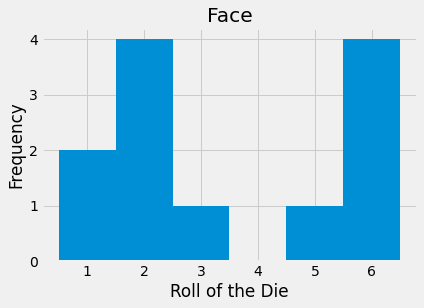

In [ ]:
#histogram
# note, starting the bins at 0.5 will give us bars centered nicely over the face numbers

roll_bins = np.arange(0.5, 7, 1)
die.sample(12, replace=True).hist(bins=roll_bins)
plt.ylabel('Frequency')
plt.xlabel('Roll of the Die')
plt.show()

What about 100 rolls?

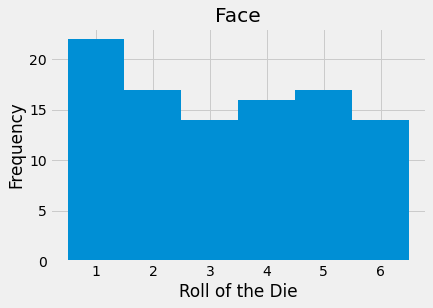

In [ ]:
die.sample(100, replace=True).hist(bins=roll_bins)
plt.ylabel('Frequency')
plt.xlabel('Roll of the Die')
plt.show()

And 1000?

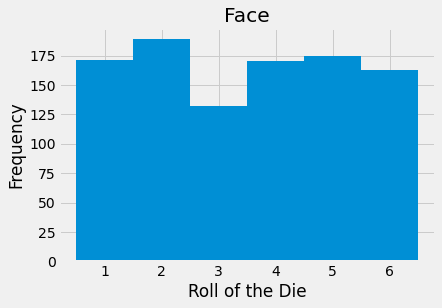

In [ ]:
die.sample(1000, replace=True).hist(bins=roll_bins)
plt.ylabel('Frequency')
plt.xlabel('Roll of the Die')
plt.show()

Should we attempt 100,000 rolls?

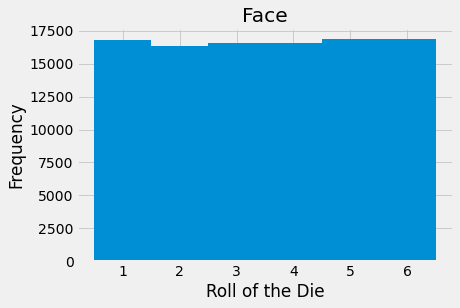

In [ ]:
die.sample(100_000, replace=True).hist(bins=roll_bins)
plt.ylabel('Frequency')
plt.xlabel('Roll of the Die')
plt.show()

The result is a histogram of observed data.

In fact, this has a special name. An **empirical distribution** is a distribution of observed data.

But we know in theory what to expect before we even roll a die....


Because each outcome here is (in theory) equally likely to occur.

The probability of equally likely events: is $P(A) = \frac{\text{number of outcomes in event A}}{\text{total number of outcomes}}$

So, the probability of rolling a 1 is $\frac{1}{6}$.

The probability of rolling a 2 is $\frac{1}{6}$.


and so on...

Text(0, 0.5, 'Probability')

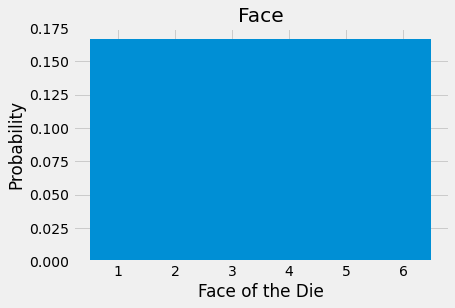

In [ ]:
die_bins = np.arange(0.5, 6.6, 1)
die.hist(bins = die_bins, density=True) #this density=True argument changes the y-axis from frequency to relative frequency
plt.xlabel('Face of the Die')
plt.ylabel('Probability')

The observed probabilities are not always so nice!

We can calculate the observed probabilies by $P(\text{'rolling the face n'}) = \frac{\text{number of times n was rolled}}{\text{Total number of rolls}}$

In [ ]:
empirical_probabilites = (die.sample(1_000, replace=True).value_counts())/1_000
empirical_probabilites

Face
1       0.180
3       0.170
4       0.167
5       0.166
2       0.164
6       0.153
Name: count, dtype: float64

array([[<AxesSubplot:title={'center':'Face'}>]], dtype=object)

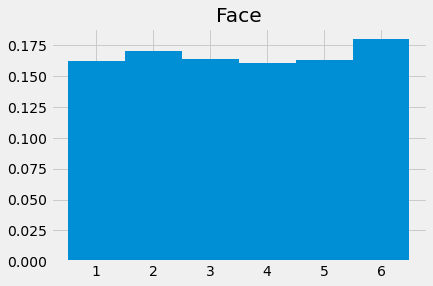

In [ ]:
die.sample(1000, replace=True).hist(bins=roll_bins, density = True)

The probabilities associated with our experiment or observation give us a **empirical probability distribution**

Whereas, as a **probability distribution** gives us our true theoretical probabilities.

Note, this example with equally likely outcomes arises in a special type of probability distribution known as the **uniform probability distribution**.

### We saw something interesting with this example!

As the number of experiments increased, our **empirical probability distribution** got closer and closer to the **probability distribution**.

This is true in general!!! (with a few conditions)
The **Law of Averages** says if we repeat an experiment a large number of times we expect the empirical results to be close to the theoretical.

Conditions for the result to hold:

 - Each experiment has no effect on any other experiment

 - Each experiment is done under the same conditions

But distributions can take on different shapes

<img src="https://github.com/SusannaLange/Data_118_images/blob/main/DSSI_images/distributions.png?raw=true" width="800">

There are certain values or statistics that are useful when discussing any probability distribution.

 - Measures of center

 - Measures of spread

The **mean** of given data is used to get a sense of the center of the distribution.

- denoted $\mu$ or $\bar{x}$

- the average of the data

- tells us the balance point of the distribution


Given finite data $x_1, x_2, ..., x_n$ the mean is $\frac{x_1 + x_2 + ...+ x_n}{n}$

The **variance** and/or the **standard deviation** are both measures of spread

 - variance is denoted $\sigma^2$

 - standard deviation is denoted $\sigma$

 - How far away from the mean is the data?


Given finite data $x_1, x_2, ..., x_n$ and mean $\mu$, the variance is $$\sigma^2  = \sum_i \frac{(x_i-\mu)^2}{n}$$

Let's consider another distribution.
Load in Galton Height Data. This contains data on father, mother, and child heights!

In [ ]:
galton_df = pd.read_csv("../../galton.csv")
galton_df.head(6)

,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,78.5,67.0,75.43,4,1,male,73.2
1,1,78.5,67.0,75.43,4,2,female,69.2
2,1,78.5,67.0,75.43,4,3,female,69.0
3,1,78.5,67.0,75.43,4,4,female,69.0
4,2,75.5,66.5,73.66,4,1,male,73.5
5,2,75.5,66.5,73.66,4,2,male,72.5


### <mark style="background-color: Thistle">Activity: Make a histogram of the heights of the fathers in the galton_df. </mark>
Use probabilities on y-axis.

In [ ]:
bin_size=np.arange(60, 80.5, 1) #use these bins

##code here

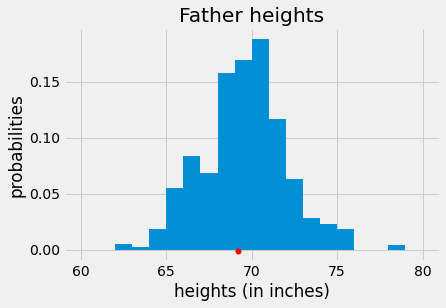

In [ ]:
##this is included here, but will be removed in the student notebook.
galton_df.hist('father', bins= bin_size, density = True)
plt.title('Father heights')
plt.xlabel('heights (in inches)')
plt.ylabel('probabilities')
plt.scatter(galton_df['father'].mean(), -0.001, color='red', s=30);
plt.show()

This is another **empirical distribution**, but a special one!
An **empirical normal distribution**.

- Unlike what we saw above, the values are continous variables.

### Normal Probability Distribution


<img src="https://github.com/SusannaLange/Data_118_images/blob/main/DSSI_images/normal_bell.png?raw=true" width="800">

Arguably the most important continuous distribution.

Describes the distributions of things such as

- height

- weight

- SAT scores

Important facts about the normal distribution:

 - A normal distribution is symmetric and bell-shaped, giving it the nickname "bell-curve".

 - The mean, median and mode are exactly the same.

 - Defined entirely by its mean and standard deviation!


If $X$ is distributed continuous Normal, then $X ∼ N(\mu,\sigma)$

Remember how we said standard deviation was a good measure of spread?! One reason is because it can be used to bound the data...


<img src="https://github.com/SusannaLange/Data_118_images/blob/main/DSSI_images/normal_sd.png?raw=true" width="800">

The special case of the normal distribution is called the **standard normal**, where $\mu=0$ and $\sigma=1$.

If $X  ∼  N(\mu, \sigma)$ then we can *transform* it to a standard normal, by normalizing it! That is:

$$\frac{X-\mu}{\sigma}$$

##### A few reasons that we care about the normal distribution.

It shows up a lot!!!

There is an important relationship between the mean of given data and a normal distribution.

### <mark style="background-color: Thistle">Investigative activity </mark>

Recall we experimented with rolling a 6 sided die? Instead of graphing the outputs themselves, let's replicate the following process:

(1) roll a fair 6 sided die 50 times

(2) record the mean over these 50 rolls

Repeat this $n$ times and graph the results!

In [ ]:
#first we have our definition of die
die = pd.DataFrame(
    {
        'Face': np.arange(1, 7),
    })

In [ ]:
def face_mean_sim(nsim):
    """Simulates nsim repetions of 50 dice rolls and returns their sample mean."""
    means = [] #we want to store our means here

    for i in np.arange(nsim):
        ?????????

    return means

We want to plot our results in a histogram:

    Let's start with n_sim = 10

In [ ]:
#code here


We can increase the number of repetitions and consider the distribution. Fill in the following code.

In [ ]:
fig, axs = plt.subplots(3, figsize=(8, 8))
fig.suptitle('Mean Dice Roll Simulation: 100, 1000, and 10000')
fig.tight_layout()
axs[0].hist(???) #repeat 100 times
axs[1].hist(???) #repeat 1000 times
axs[2].hist(????) #repeat 10000 times
plt.show()

What do you notice?

Answer here

The distributions are looking more bell shaped as we increase the number of repetitions!

This is because of the **Central Limit Theorem**!

If you take sufficiently large random samples from a population with replacement, the distribution of sample means will be approximately normally distributed **regardless of the original distribution!!**


Why is this useful?!

We may not know what the population looks like, but this allows us to get a good estimate of a statistic (like the sample mean or proportion)

Why did we need distributions? And why do we care?!


In order to make statistical conclusions about your data, you need some idea of

 - the shape of the data

 - information and understanding about its mean, variance, standard deviation

### <mark style="background-color: Thistle">Concept Check </mark>

Summarize 2 important concepts from this notebook. See if your highlights agree with your neighbor/group.

1.

2.